# Análisis exploratorio de fallas en bombas eléctricas sumergibles (ESP/BEC)

**Proyecto de Análisis de Datos aplicado a Oil & Gas y diagnóstico de fallas**

Este proyecto explora características extraídas de señales de vibración para reconocer patrones, diferencias y relaciones asociadas con el funcionamiento normal y distintos tipos de falla en bombas eléctricas sumergibles.

> **Alcance:** comprensión del problema, revisión de calidad, distribuciones, comparación visual entre condiciones y análisis de correlaciones. No se entrenan modelos predictivos en esta etapa.

**Herramientas:** Python, Pandas, NumPy, Matplotlib y Seaborn.

**Fuente de datos:** [ESPset — repositorio oficial](https://github.com/NINFA-UFES/ESPset) · [Mendeley Data](https://doi.org/10.17632/m268jsw339.1) · Licencia CC BY 4.0.

## Índice navegable

1. [Introducción al proyecto](#scrollTo=8cbd910b)
   - [Contexto](#scrollTo=intro-context)
   - [Pregunta de negocio](#scrollTo=intro-question)
   - [Objetivo](#scrollTo=intro-objective)
   - [Descripción del conjunto de datos](#scrollTo=intro-dataset)
   - [Descripción de las variables](#scrollTo=intro-variables)
2. [Carga y comprensión inicial](#scrollTo=ld5lgPh_BDlq)
   - [Importación de librerías](#scrollTo=import-libraries)
   - [Carga de datos](#scrollTo=6a87c689)
3. [Preparación y calidad de datos](#scrollTo=FhpFojHPBDlt)
   - [Valores faltantes](#scrollTo=missing-values)
   - [Valores únicos](#scrollTo=ymKCtT2TBDlt)
   - [Duplicados](#scrollTo=GSAVU8xXBDlt)
   - [Identificador de equipo](#scrollTo=qgQTXkK-BDlt)
   - [Variable de condición](#scrollTo=2809f158)
   - [Distribución de las condiciones](#scrollTo=cfc9812f)
     - [Cobertura de bombas por condición](#scrollTo=coverage-heading)
   - [Variables para el análisis](#scrollTo=e90ea926)
4. [Análisis exploratorio](#scrollTo=E5GxDoOeBDlv)
   - [Estadísticos descriptivos](#scrollTo=descriptive-stats)
   - [Distribuciones](#scrollTo=EMk6NTc4BDlv)
   - [Histogramas](#scrollTo=U0Z-36z4BDlv)
   - [Boxplots](#scrollTo=022Xm0iVBDlv)
   - [Valores atípicos](#scrollTo=Ef9wSXVcBDlv)
   - [Distribución de variables clave por condición](#scrollTo=e0893b5a)
   - [Solapamiento entre peak1x y peak2x](#scrollTo=67ec6618)
   - [Rango intercuartílico por condición](#scrollTo=3f63463b)
5. [Correlaciones](#scrollTo=xxOOLZ39BDlw)
   - [Matriz de correlación](#scrollTo=correlation-matrix)
   - [Mapa de calor](#scrollTo=QShUpa_zBDlw)
   - [Pairplot de variables relevantes](#scrollTo=ba5db204)
   - [Correlación según grupo operativo](#scrollTo=1a82c636)
   - [Interpretación](#scrollTo=dde0ae66)
6. [Conclusiones](#scrollTo=778138ab)
7. [Limitaciones del análisis](#scrollTo=limitations-section)
8. [Posibles aplicaciones y próximos pasos](#scrollTo=next-steps-section)


<a id="seccion-1"></a>
## 1. Introducción al proyecto


<a id="seccion-1-1"></a>
### 1.1. Contexto

Las bombas eléctricas sumergibles (**ESP**, por sus siglas en inglés; **BEC** en español) son sistemas de levantamiento artificial utilizados en la industria de petróleo y gas. Trabajan bajo condiciones exigentes y una falla puede afectar la continuidad operativa, los costos de mantenimiento y la producción.

Las vibraciones generadas durante su operación contienen información sobre el comportamiento mecánico del equipo. El análisis de estas señales puede ayudar a reconocer patrones compatibles con condiciones normales o con distintos mecanismos de falla.


<a id="seccion-1-2"></a>
### 1.2. Pregunta de negocio

**¿Qué patrones, diferencias y relaciones se observan en las características extraídas de señales de vibración correspondientes a condiciones normales y distintos tipos de falla en bombas ESP/BEC?**


<a id="seccion-1-3"></a>
### 1.3. Objetivo del proyecto

Explorar las características extraídas de señales de vibración del dataset ESPset para evaluar la calidad de los datos, describir sus distribuciones, comparar el comportamiento de las variables entre condiciones de funcionamiento y analizar las relaciones existentes entre ellas.


<a id="seccion-1-4"></a>
### 1.4. Descripción del conjunto de datos

Se utiliza `features.csv` del conjunto público **ESPset**, publicado por investigadores de la Universidade Federal do Espírito Santo. Contiene 6.032 observaciones de señales de vibración, 11 bombas y cinco condiciones: funcionamiento normal, desbalance, roce, sensor defectuoso y desalineación. Las señales fueron adquiridas durante ensayos de vibración realizados antes de la instalación definitiva de los equipos en pozos petroleros.

- Repositorio oficial y documentación: [NINFA-UFES/ESPset](https://github.com/NINFA-UFES/ESPset)
- Dataset y licencia CC BY 4.0: [Mendeley Data — DOI 10.17632/m268jsw339.1](https://doi.org/10.17632/m268jsw339.1)
- Artículo asociado: [Knowledge-Based Systems — DOI 10.1016/j.knosys.2024.111452](https://doi.org/10.1016/j.knosys.2024.111452)


<a id="seccion-1-5"></a>
### 1.5. Descripción de las variables

- `id`: identificador de la observación.
- `esp_id`: identificador de la bomba de origen.
- `label`: condición de funcionamiento asignada a la señal.
- `median(8,13)`: mediana de amplitudes entre 8 % y 13 % de la frecuencia de rotación.
- `rms(98,102)`: RMS de amplitudes entre 98 % y 102 % de la frecuencia de rotación.
- `median(98,102)`: mediana de amplitudes entre 98 % y 102 % de la frecuencia de rotación.
- `peak1x`: amplitud en la frecuencia fundamental de rotación (1X).
- `peak2x`: amplitud en el segundo armónico de la frecuencia de rotación (2X).
- `a` y `b`: coeficientes del ajuste exponencial utilizado para resumir el espectro de bajas frecuencias.


<a id="seccion-2"></a>
## 2. Carga y comprensión inicial de los datos


<a id="seccion-2-1"></a>
### 2.1. Importación de librerías


In [1]:
import os

# Matplotlib guardará su caché dentro del proyecto para evitar
# problemas de permisos en distintos entornos.
os.environ["MPLCONFIGDIR"] = os.path.abspath(".matplotlib-cache")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


<a id="seccion-2-2"></a>
### 2.2. Carga del archivo `features.csv`

El archivo se guarda de forma persistente en Google Drive. Al iniciar una nueva sesión de Colab, se monta Drive y se carga desde la carpeta `analisis-exploratorio-fallas-esp/data`, sin necesidad de volver a subirlo.

In [2]:
from pathlib import Path

ruta_local = Path("data/features.csv")

if ruta_local.exists():
    ruta_datos = ruta_local
else:
    from google.colab import drive

    drive.mount("/content/drive")
    ruta_datos = Path(
        "/content/drive/MyDrive/"
        "analisis-exploratorio-fallas-esp/data/features.csv"
    )

df = pd.read_csv(ruta_datos, sep=";")

print(
    f"Dataset cargado correctamente: "
    f"{df.shape[0]:,} filas y {df.shape[1]} columnas."
)


Dataset cargado correctamente: 6,032 filas y 10 columnas.


In [3]:
df.head()

,id,esp_id,label,"median(8,13)","rms(98,102)","median(98,102)",peak1x,peak2x,a,b
0,0,7,Normal,0.002170,0.073935,0.000745,0.04894,0.01040,-0.000253,-6.485689
1,1,0,Normal,0.000290,0.266436,0.002295,0.15950,0.02152,-0.000546,-7.630209
2,2,4,Normal,0.042025,0.171981,0.004265,0.11314,0.02472,-0.003483,-2.293972
3,3,5,Normal,0.000915,0.060911,0.000310,0.03801,0.00534,-0.000960,-6.725640
4,4,7,Normal,0.001235,0.105685,0.001320,0.06891,0.00479,-0.000497,-6.407991


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6032 entries, 0 to 6031
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              6032 non-null   int64  
 1   esp_id          6032 non-null   int64  
 2   label           6032 non-null   str    
 3   median(8,13)    6032 non-null   float64
 4   rms(98,102)     6032 non-null   float64
 5   median(98,102)  6032 non-null   float64
 6   peak1x          6032 non-null   float64
 7   peak2x          6032 non-null   float64
 8   a               6032 non-null   float64
 9   b               6032 non-null   float64
dtypes: float64(7), int64(2), str(1)
memory usage: 471.4 KB


El conjunto de datos contiene 6.032 observaciones y 10 columnas. No se observan valores nulos en esta primera revisión. Las columnas `id` y `esp_id` funcionan como identificadores, `label` representa la condición de funcionamiento y las siete columnas restantes contienen características numéricas extraídas de las señales de vibración.

Esta revisión permite comprender la estructura inicial del dataset. La evaluación de su calidad continúa con el análisis de duplicados, valores únicos, distribuciones y posibles valores atípicos.


<a id="seccion-3"></a>
## 3. Preparación y calidad de datos


<a id="seccion-3-1"></a>
### 3.1. Valores faltantes


In [5]:
nulos = df.isna().sum().to_frame(name="cantidad_nulos")
nulos["porcentaje"] = (nulos["cantidad_nulos"] / len(df) * 100).round(2)
nulos

,cantidad_nulos,porcentaje
id,0,0.0
esp_id,0,0.0
label,0,0.0
"median(8,13)",0,0.0
"rms(98,102)",0,0.0
"median(98,102)",0,0.0
peak1x,0,0.0
peak2x,0,0.0
a,0,0.0
b,0,0.0


**Interpretación:**  
No hay valores nulos, ni faltantes.


<a id="seccion-3-2"></a>
### 3.2. Valores únicos


In [6]:
unicos = df.nunique(dropna=False).to_frame(name="valores_unicos")
unicos

,valores_unicos
id,6032
esp_id,11
label,5
"median(8,13)",1423
"rms(98,102)",5960
"median(98,102)",991
peak1x,4655
peak2x,1895
a,5964
b,5964


<a id="seccion-3-3"></a>
### 3.3. Registros duplicados


In [7]:
duplicados = df.duplicated().sum()
porcentaje_duplicados = duplicados / len(df) * 100

print(f"Registros duplicados completos: {duplicados}")
print(f"Porcentaje de duplicados: {porcentaje_duplicados:.2f}%")

Registros duplicados completos: 0
Porcentaje de duplicados: 0.00%


<a id="seccion-3-4"></a>
### 3.4. Revisión de esp_id


In [8]:
df["esp_id"].value_counts().sort_index().to_frame("cantidad")

,cantidad
esp_id,
0,252
1,747
2,300
3,420
4,800
5,830
6,378
7,684
8,486


`esp_id` identifica la bomba de origen de cada observación. Se conserva como información de contexto, pero no representa una medición de la señal y por eso no se incluye entre las variables numéricas del análisis.


<a id="seccion-3-5"></a>
### 3.5. Revisión de la variable de condición `label`


In [9]:
print("Condiciones presentes:")
print(sorted(df["label"].unique()))
print(f"\nCantidad de condiciones: {df['label'].nunique()}")

Condiciones presentes:
['Faulty sensor', 'Misalignment', 'Normal', 'Rubbing', 'Unbalance']

Cantidad de condiciones: 5


<a id="seccion-3-6"></a>
### 3.6. Distribución de las condiciones


In [10]:
distribucion_label = df["label"].value_counts().to_frame("Cantidad")
distribucion_label["Porcentaje"] = (
    df["label"].value_counts(normalize=True) * 100
).round(2)

distribucion_label

,Cantidad,Porcentaje
label,,
Normal,4801,79.59
Unbalance,576,9.55
Faulty sensor,295,4.89
Rubbing,290,4.81
Misalignment,70,1.16


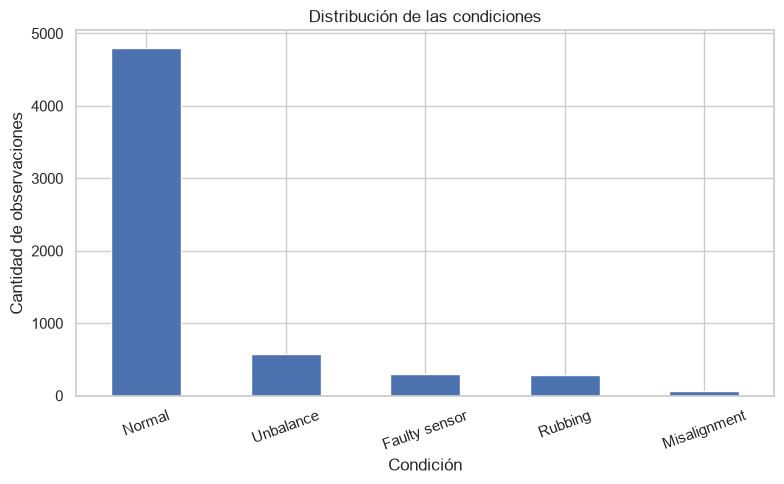

In [11]:
plt.figure(figsize=(8, 5))

distribucion_label["Cantidad"].plot(
    kind="bar",
    color="#4C72B0"
)

plt.title("Distribución de las condiciones")
plt.xlabel("Condición")
plt.ylabel("Cantidad de observaciones")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


La condición `Normal` representa el 79,59 % de las observaciones, mientras que `Misalignment` constituye el 1,16 %. Esta distribución desigual no representa un error del análisis, sino una característica relevante de la composición del conjunto de datos.

Como las mediciones provienen de ensayos realizados antes de la instalación definitiva de las bombas, estas proporciones no deben interpretarse directamente como la frecuencia real de las condiciones durante la operación en campo. Aun así, la baja representación de algunas condiciones plantea un desafío habitual para el análisis de fallas.

En una futura etapa de modelado sería necesario evaluar el desempeño por condición y separar los datos considerando la bomba de origen (`esp_id`). Identificar estas características durante el análisis exploratorio permite anticipar decisiones metodológicas y evitar resultados dominados por la clase mayoritaria o por observaciones muy similares de un mismo equipo.


<a id="seccion-3-6-1"></a>
#### 3.6.1. Cobertura de bombas por condición


label,Normal,Unbalance,Rubbing,Faulty sensor,Misalignment
esp_id,,,,,
0,201,51,0,0,0
1,644,34,46,23,0
2,277,1,12,10,0
3,347,6,56,11,0
4,578,103,7,60,52
5,614,58,79,79,0
6,272,102,0,4,0
7,612,72,0,0,0
8,309,69,0,108,0


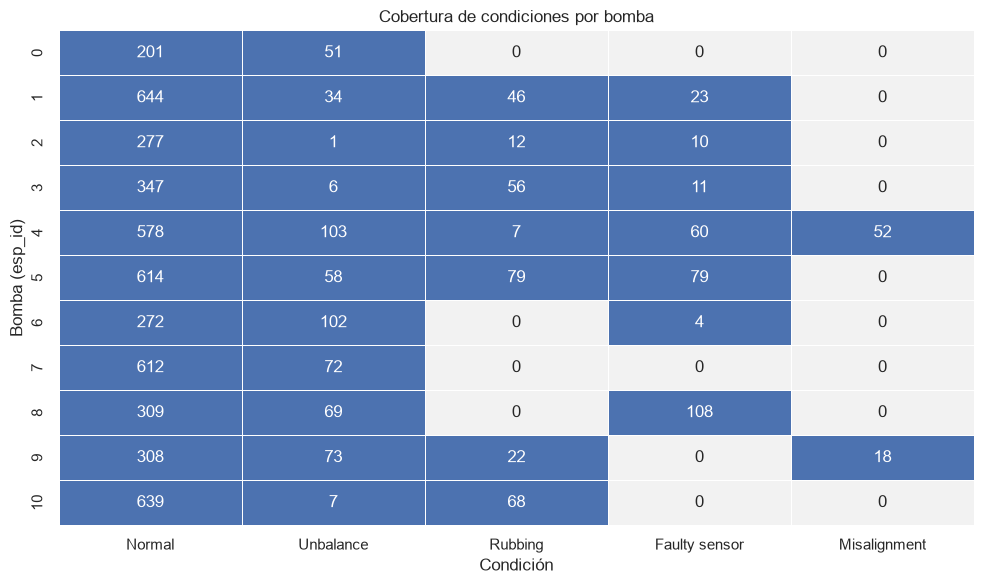

In [12]:
orden_condiciones = [
    "Normal",
    "Unbalance",
    "Rubbing",
    "Faulty sensor",
    "Misalignment"
]

tabla_bomba_condicion = pd.crosstab(
    df["esp_id"],
    df["label"]
).reindex(columns=orden_condiciones, fill_value=0)

display(tabla_bomba_condicion)

presencia_condicion = tabla_bomba_condicion.gt(0).astype(int)
mapa_presencia = sns.color_palette(
    ["#F2F2F2", "#4C72B0"],
    as_cmap=True
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    presencia_condicion,
    annot=tabla_bomba_condicion,
    fmt="d",
    cmap=mapa_presencia,
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)
plt.title("Cobertura de condiciones por bomba")
plt.xlabel("Condición")
plt.ylabel("Bomba (esp_id)")
plt.tight_layout()
plt.show()


La tabla cruzada y el mapa de cobertura permiten distinguir cantidad de observaciones y diversidad de equipos. Las celdas azules indican que una combinación bomba–condición está representada; el número muestra cuántas observaciones contiene.

`Normal` y `Unbalance` aparecen en las 11 bombas, mientras que `Faulty sensor` y `Rubbing` están presentes en 7. `Misalignment` se limita a las bombas 4 y 9. Por lo tanto, parte de las diferencias atribuidas a esta última condición también podría estar relacionada con las características particulares de esos dos equipos. Esta limitación debe considerarse antes de generalizar los resultados.


<a id="seccion-3-7"></a>
### 3.7. Selección de variables para el análisis


In [13]:
columnas_identificacion = ["id", "esp_id", "label"]
variables_numericas = [
    columna for columna in df.columns
    if columna not in columnas_identificacion
]
datos_numericos = df[variables_numericas]

print("Variables numéricas analizadas:")
print(variables_numericas)


Variables numéricas analizadas:
['median(8,13)', 'rms(98,102)', 'median(98,102)', 'peak1x', 'peak2x', 'a', 'b']


<a id="seccion-4"></a>
## 4. Análisis Exploratorio de Datos — EDA


<a id="seccion-4-1"></a>
### 4.1. Estadísticos descriptivos


In [14]:
datos_numericos.describe().T

,count,mean,std,min,25%,50%,75%,max
"median(8,13)",6032.0,0.009197,0.075649,0.000010,0.000740,0.001200,0.002220,2.428575
"rms(98,102)",6032.0,0.156574,0.152307,0.000000,0.076672,0.130494,0.197573,2.221899
"median(98,102)",6032.0,0.001760,0.002691,0.000000,0.000885,0.001328,0.002001,0.074750
peak1x,6032.0,0.079368,0.063705,0.000000,0.030110,0.070360,0.116060,0.570300
peak2x,6032.0,0.007380,0.007340,0.000000,0.002100,0.005240,0.010090,0.064820
a,6032.0,-0.000740,0.001156,-0.016420,-0.001114,-0.000559,-0.000078,0.002278
b,6032.0,-6.223028,1.299861,-14.468829,-6.965702,-6.487585,-5.882774,1.664554


<a id="seccion-4-2"></a>
### 4.2. Distribución de variables numéricas


In [15]:
resumen_distribucion = pd.DataFrame({
    "media": datos_numericos.mean(),
    "mediana": datos_numericos.median(),
    "desvio_std": datos_numericos.std(),
    "asimetria": datos_numericos.skew(),
    "min": datos_numericos.min(),
    "max": datos_numericos.max()
})

resumen_distribucion

,media,mediana,desvio_std,asimetria,min,max
"median(8,13)",0.009197,0.001200,0.075649,18.930852,0.000010,2.428575
"rms(98,102)",0.156574,0.130494,0.152307,6.262392,0.000000,2.221899
"median(98,102)",0.001760,0.001328,0.002691,14.408429,0.000000,0.074750
peak1x,0.079368,0.070360,0.063705,1.047873,0.000000,0.570300
peak2x,0.007380,0.005240,0.007340,1.916075,0.000000,0.064820
a,-0.000740,-0.000559,0.001156,-2.773448,-0.016420,0.002278
b,-6.223028,-6.487585,1.299861,1.949418,-14.468829,1.664554


La asimetría permite observar si una distribución se extiende principalmente hacia valores altos o bajos. Las variables `median(8,13)` y `median(98,102)` presentan una asimetría positiva pronunciada: la mayoría de sus observaciones se concentra en valores pequeños, junto con una cantidad reducida de registros considerablemente más altos.

También existen diferencias importantes de escala entre las variables, especialmente en `b`, cuyos valores son principalmente negativos. En esta etapa exploratoria no se realizan transformaciones, ya que el objetivo es describir el comportamiento original de los datos.


<a id="seccion-4-3"></a>
### 4.3. Histogramas


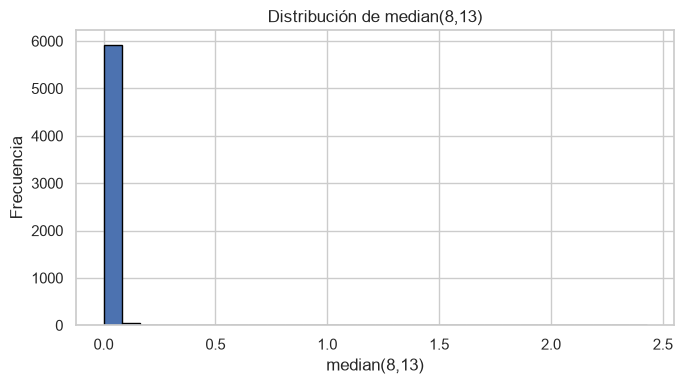

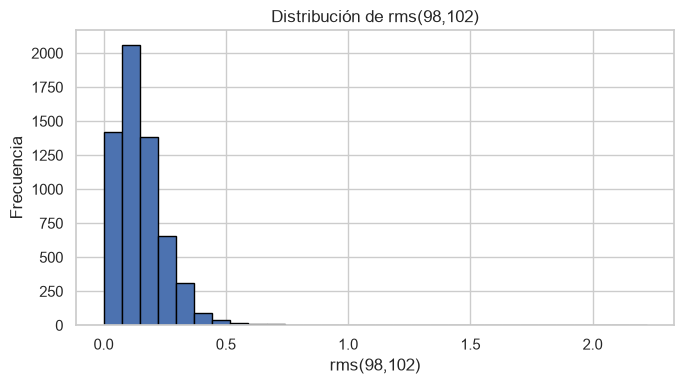

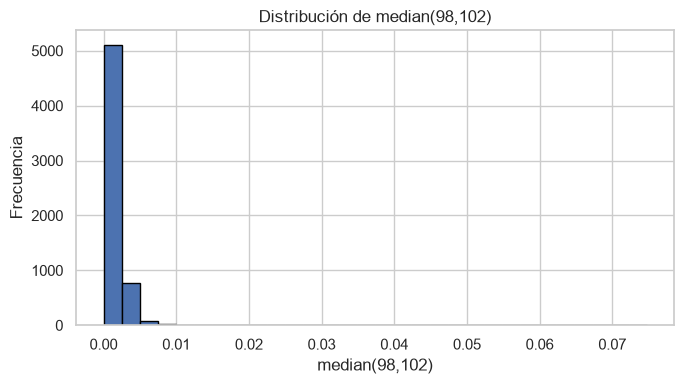

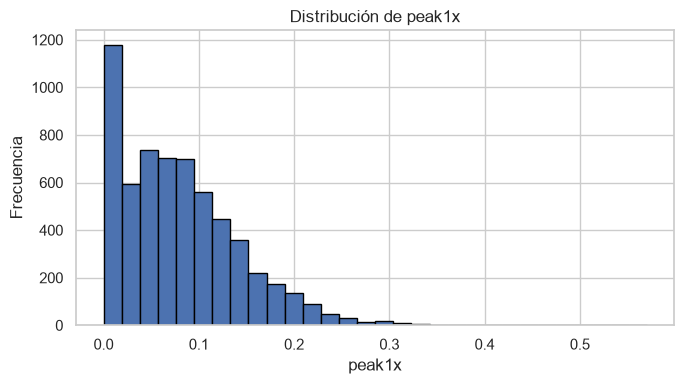

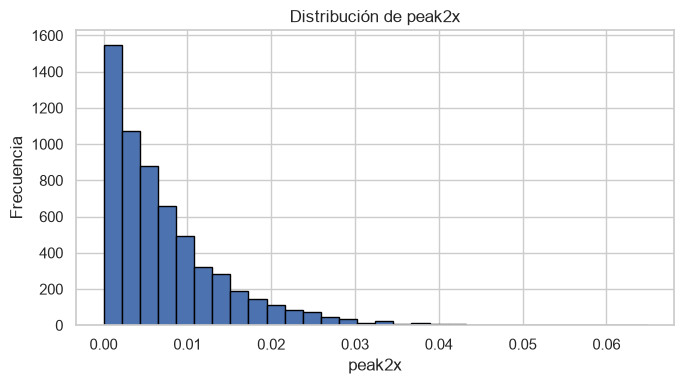

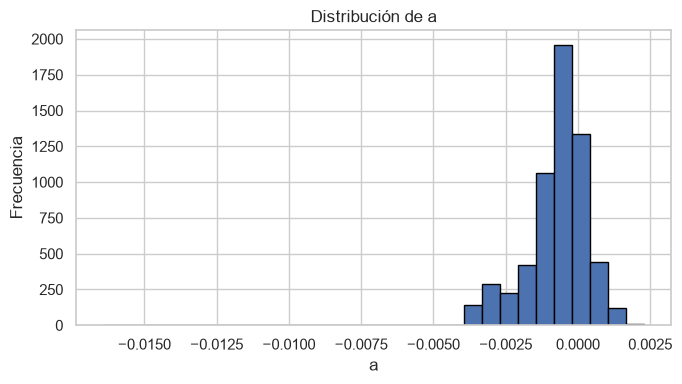

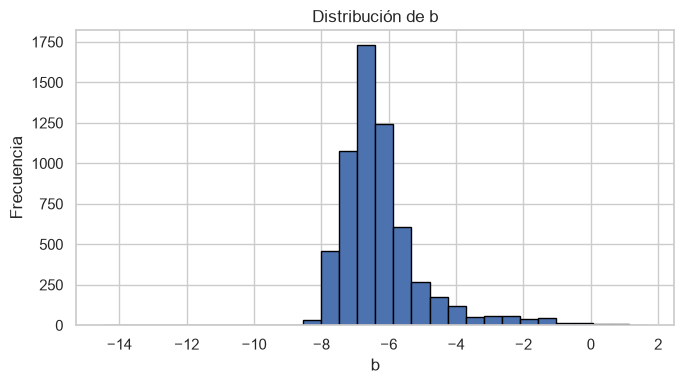

In [16]:
for columna in variables_numericas:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(datos_numericos[columna], bins=30, edgecolor="black")
    ax.set_title(f"Distribución de {columna}")
    ax.set_xlabel(columna)
    ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


<a id="seccion-4-4"></a>
### 4.4. Boxplots


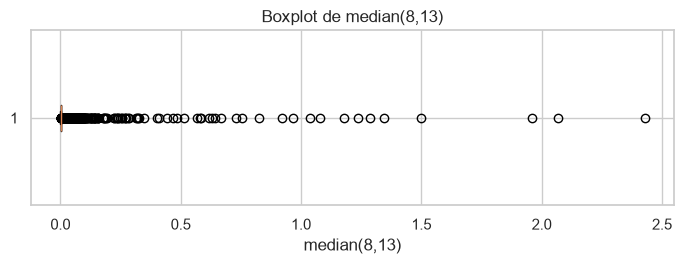

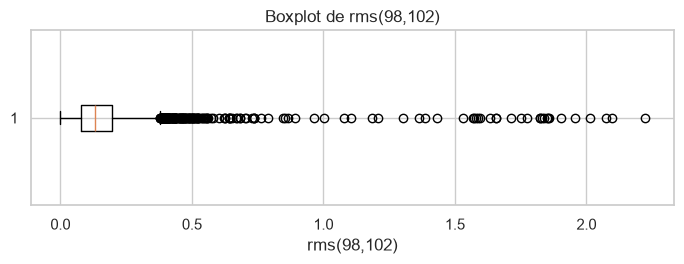

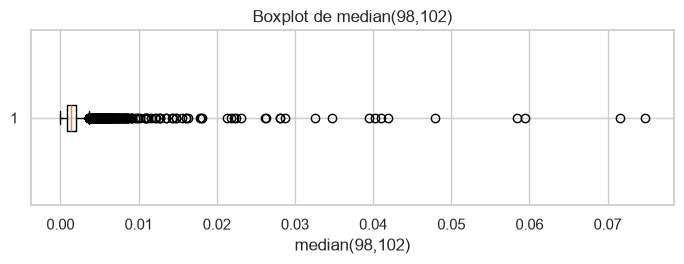

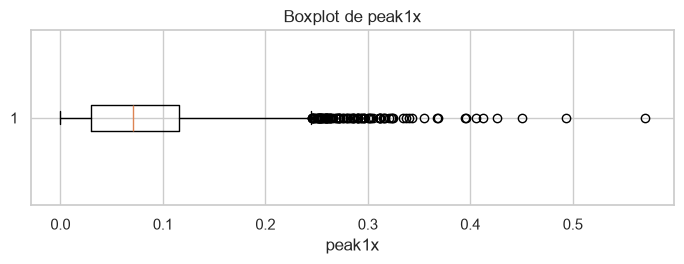

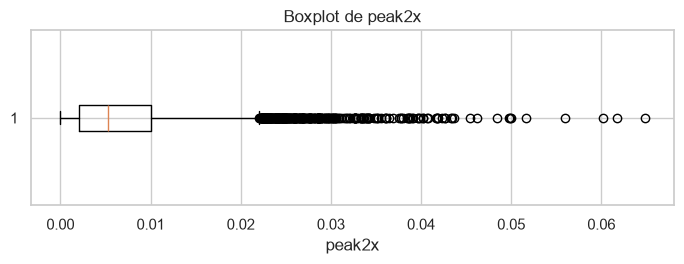

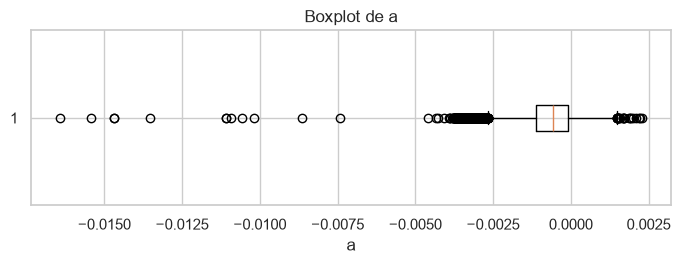

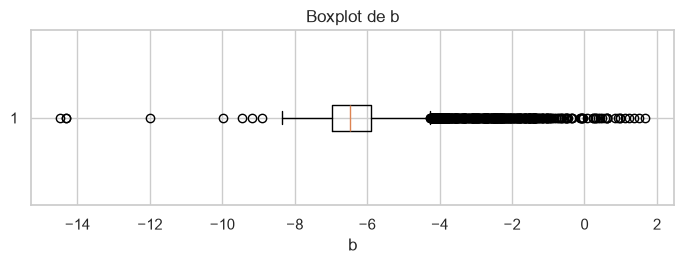

In [17]:
for columna in variables_numericas:
    fig, ax = plt.subplots(figsize=(7, 2.8))
    ax.boxplot(datos_numericos[columna], orientation="horizontal")
    ax.set_title(f"Boxplot de {columna}")
    ax.set_xlabel(columna)
    plt.tight_layout()
    plt.show()


<a id="seccion-4-5"></a>
### 4.5. Posibles valores atípicos


In [18]:
def resumen_outliers_iqr(dataframe):
    resultados = []

    for columna in dataframe.select_dtypes(include=np.number).columns:
        serie = dataframe[columna].dropna()

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]

        resultados.append({
            "variable": columna,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "cantidad_outliers_IQR": len(outliers),
            "porcentaje_outliers_IQR": round(len(outliers) / len(serie) * 100, 2)
        })

    return pd.DataFrame(resultados)

resumen_outliers = resumen_outliers_iqr(datos_numericos)
resumen_outliers

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers_IQR,porcentaje_outliers_IQR
0,"median(8,13)",0.000740,0.002220,0.001480,-0.001480,0.004440,675,11.19
1,"rms(98,102)",0.076672,0.197573,0.120901,-0.104680,0.378925,190,3.15
2,"median(98,102)",0.000885,0.002001,0.001116,-0.000789,0.003676,320,5.31
3,peak1x,0.030110,0.116060,0.085950,-0.098815,0.244985,92,1.53
4,peak2x,0.002100,0.010090,0.007990,-0.009885,0.022075,310,5.14
5,a,-0.001114,-0.000078,0.001035,-0.002667,0.001475,487,8.07
6,b,-6.965702,-5.882774,1.082928,-8.590094,-4.258381,433,7.18


El método IQR identifica que entre el 1,5 % y el 11,2 % de las observaciones de cada variable se encuentra fuera de los límites estadísticos convencionales. En datos de vibración, estos valores podrían corresponder a eventos operativos relevantes, variaciones propias del equipo o posibles anomalías.

Sin embargo, el análisis estadístico por sí solo no permite determinar su causa. Por este motivo, los registros se conservan sin modificaciones y se documenta su presencia para una futura validación con especialistas en vibraciones o mantenimiento.


<a id="seccion-4-6"></a>
### 4.6. Distribución de variables clave por condición

Los violin plots combinan la forma de la distribución con los cuartiles internos. Se utilizan para profundizar en `peak1x` y `peak2x`, las variables que mostraron las diferencias más claras entre algunas condiciones.


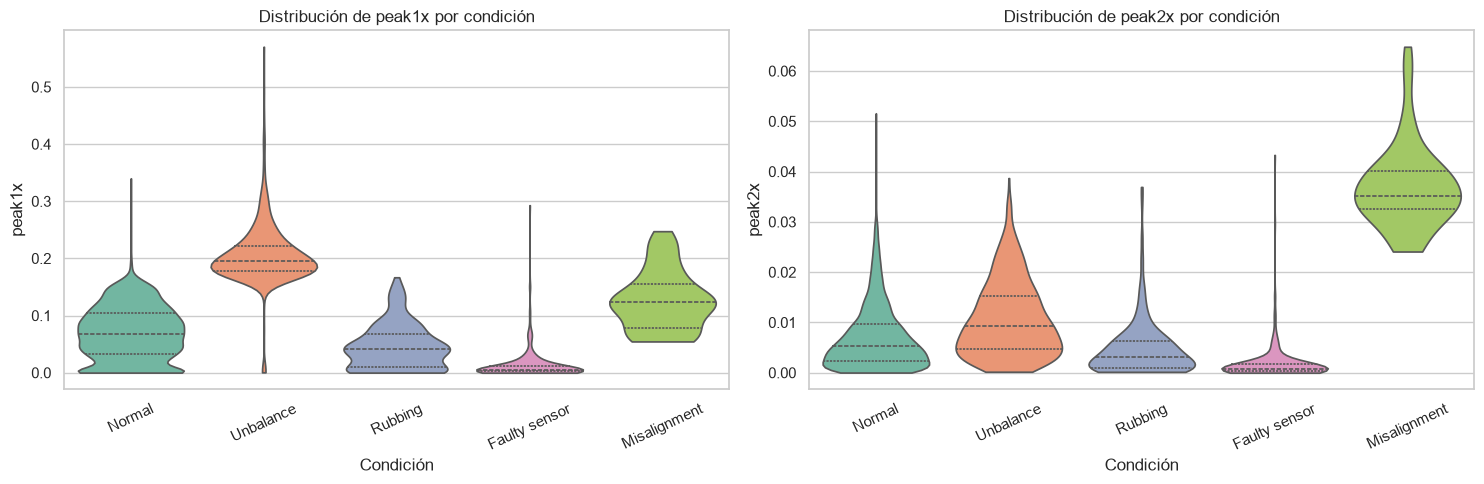

In [19]:
paleta_condiciones = dict(zip(
    orden_condiciones,
    sns.color_palette("Set2", n_colors=len(orden_condiciones))
))

variables_clave = ["peak1x", "peak2x"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for eje, variable in zip(axes, variables_clave):
    sns.violinplot(
        data=df,
        x="label",
        y=variable,
        order=orden_condiciones,
        hue="label",
        palette=paleta_condiciones,
        inner="quartile",
        cut=0,
        density_norm="width",
        legend=False,
        ax=eje
    )
    eje.set_title(f"Distribución de {variable} por condición")
    eje.set_xlabel("Condición")
    eje.set_ylabel(variable)
    eje.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


Los violines confirman que `Unbalance` concentra valores más altos de `peak1x` y que `Misalignment` presenta los valores centrales más elevados de `peak2x`. Sin embargo, `Normal`, `Rubbing` y `Faulty sensor` mantienen zonas de solapamiento. Esto indica que una sola característica no basta para describir todas las condiciones.

<a id="seccion-4-7"></a>
### 4.7. Solapamiento entre `peak1x` y `peak2x`

El scatterplot permite observar conjuntamente las dos variables clave. La transparencia evita que las zonas con muchas observaciones oculten completamente a los grupos menos frecuentes.


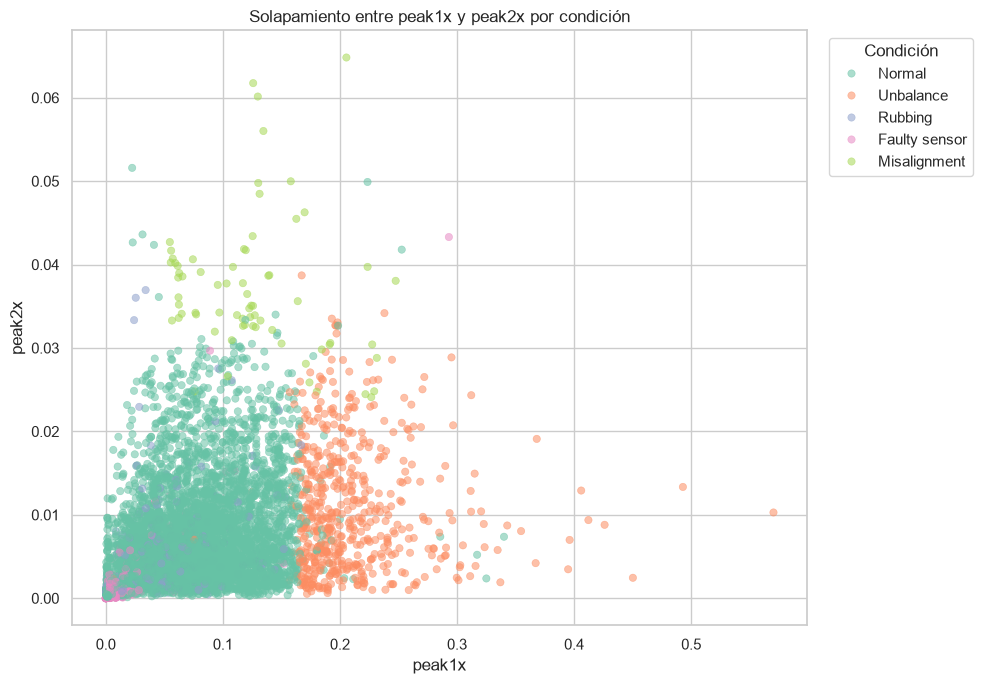

In [20]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="peak1x",
    y="peak2x",
    hue="label",
    hue_order=orden_condiciones,
    palette=paleta_condiciones,
    alpha=0.55,
    s=28,
    edgecolor=None
)

plt.title("Solapamiento entre peak1x y peak2x por condición")
plt.xlabel("peak1x")
plt.ylabel("peak2x")
plt.legend(title="Condición", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

Path("assets").mkdir(exist_ok=True)
plt.savefig(
    "assets/solapamiento_peak1x_peak2x.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()


La combinación de ambas variables mejora la lectura respecto de analizarlas por separado: `Unbalance` se desplaza principalmente hacia valores altos de `peak1x`, mientras que `Misalignment` se concentra en valores altos de `peak2x`. Aun así, existe una región compartida —especialmente entre `Normal`, `Rubbing` y `Faulty sensor`— que impide establecer fronteras simples solo con estas dos características.

<a id="seccion-4-8"></a>
### 4.8. Rango intercuartílico por condición

Para cuantificar las zonas centrales observadas en los gráficos se calculan el primer cuartil (Q1), la mediana, el tercer cuartil (Q3) y el rango intercuartílico (IQR = Q3 − Q1) de `peak1x` y `peak2x` para cada condición.


In [21]:
filas_iqr = []

for condicion, grupo in df.groupby("label"):
    for variable in variables_clave:
        q1 = grupo[variable].quantile(0.25)
        mediana = grupo[variable].median()
        q3 = grupo[variable].quantile(0.75)

        filas_iqr.append({
            "condicion": condicion,
            "variable": variable,
            "Q1": q1,
            "mediana": mediana,
            "Q3": q3,
            "IQR": q3 - q1
        })

tabla_iqr = pd.DataFrame(filas_iqr)
tabla_iqr[["Q1", "mediana", "Q3", "IQR"]] = (
    tabla_iqr[["Q1", "mediana", "Q3", "IQR"]].round(5)
)

tabla_iqr


,condicion,variable,Q1,mediana,Q3,IQR
0,Faulty sensor,peak1x,0.00330,0.00419,0.01186,0.00856
1,Faulty sensor,peak2x,0.00036,0.00082,0.00170,0.00135
2,Misalignment,peak1x,0.07813,0.12296,0.15604,0.07791
3,Misalignment,peak2x,0.03253,0.03514,0.04010,0.00757
4,Normal,peak1x,0.03250,0.06813,0.10435,0.07185
5,Normal,peak2x,0.00236,0.00528,0.00975,0.00739
6,Rubbing,peak1x,0.01045,0.04087,0.06781,0.05736
7,Rubbing,peak2x,0.00088,0.00321,0.00636,0.00548
8,Unbalance,peak1x,0.17861,0.19599,0.22185,0.04324
9,Unbalance,peak2x,0.00472,0.00922,0.01528,0.01056


Los intervalos centrales refuerzan la interpretación visual. En `peak1x`, el 50 % central de `Unbalance` se encuentra aproximadamente entre 0,179 y 0,222, por encima del resto de las condiciones. En `peak2x`, el intervalo central de `Misalignment` se ubica entre 0,033 y 0,040, también por encima de los demás grupos. En cambio, los intervalos de `Normal`, `Rubbing` y `Faulty sensor` muestran mayor proximidad, coherente con el solapamiento observado.

Desde una perspectiva física, el mayor `peak1x` observado en `Unbalance` y el mayor `peak2x` en `Misalignment` son consistentes con firmas clásicas del análisis de vibraciones en maquinaria rotativa. El desbalanceo mecánico suele reflejarse en una amplitud elevada a la frecuencia fundamental de rotación (1X), mientras que la desalineación puede presentar componentes en 1X y 2X.

Esta coincidencia refuerza la plausibilidad física de los patrones observados, pero no constituye por sí sola un diagnóstico. En una evaluación real también deberían considerarse la dirección de medición, la fase, otros armónicos, la condición de carga y el contexto del equipo. Por ello, esta interpretación se plantea como una hipótesis razonable que requeriría validación con especialistas en vibraciones y mantenimiento. Referencia técnica complementaria: [Fluke — diagnóstico de desbalanceo y desalineación](https://www.fluke.com/en-gb/learn/blog/alignment/understanding-vibration-monitoring-common-faults-part-4).

<a id="seccion-5"></a>
## 5. Análisis de correlación


<a id="seccion-5-1"></a>
### 5.1. Matriz de correlación


In [22]:
matriz_correlacion = datos_numericos.corr()
matriz_correlacion.round(3)


,"median(8,13)","rms(98,102)","median(98,102)",peak1x,peak2x,a,b
"median(8,13)",1.000,0.107,0.755,-0.016,0.040,-0.202,0.472
"rms(98,102)",0.107,1.000,0.395,0.508,0.112,-0.009,0.103
"median(98,102)",0.755,0.395,1.000,0.211,0.184,-0.089,0.420
peak1x,-0.016,0.508,0.211,1.000,0.370,0.116,-0.075
peak2x,0.040,0.112,0.184,0.370,1.000,0.090,0.041
a,-0.202,-0.009,-0.089,0.116,0.090,1.000,-0.584
b,0.472,0.103,0.420,-0.075,0.041,-0.584,1.000


<a id="seccion-5-2"></a>
### 5.2. Mapa de calor


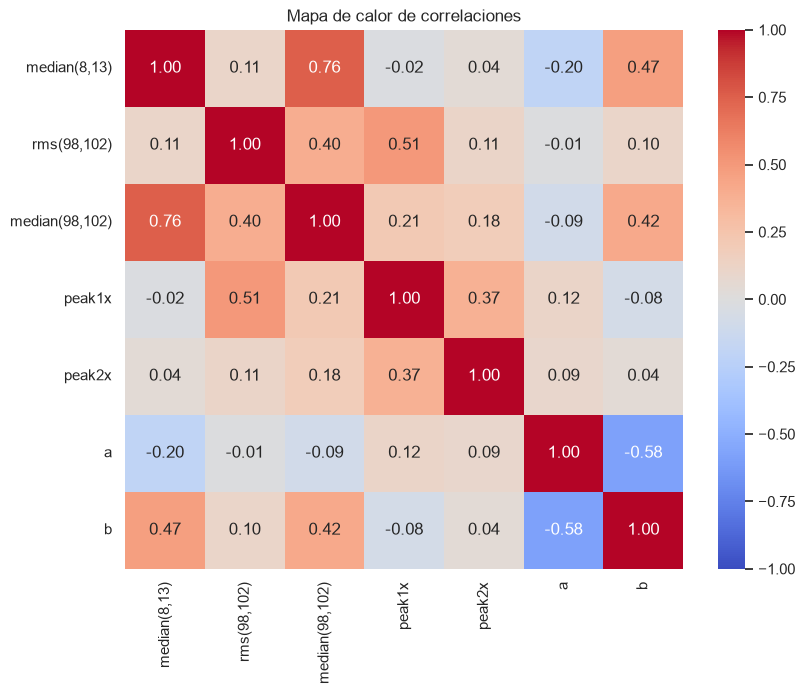

In [23]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Mapa de calor de correlaciones")
plt.show()

<a id="seccion-5-3"></a>
### 5.3. Pairplot de variables relevantes

El pairplot combina distribuciones y relaciones bivariadas para `peak1x`, `peak2x`, `a` y `b`. Esta selección reúne las dos variables con diferencias más visibles entre condiciones y el par con la relación negativa global más marcada.

Para que la clase `Normal` no oculte visualmente a las fallas, se utiliza una muestra balanceada de 70 observaciones por condición, igual al tamaño del grupo menos frecuente. Esta muestra se emplea únicamente para visualización y no modifica el dataset original.


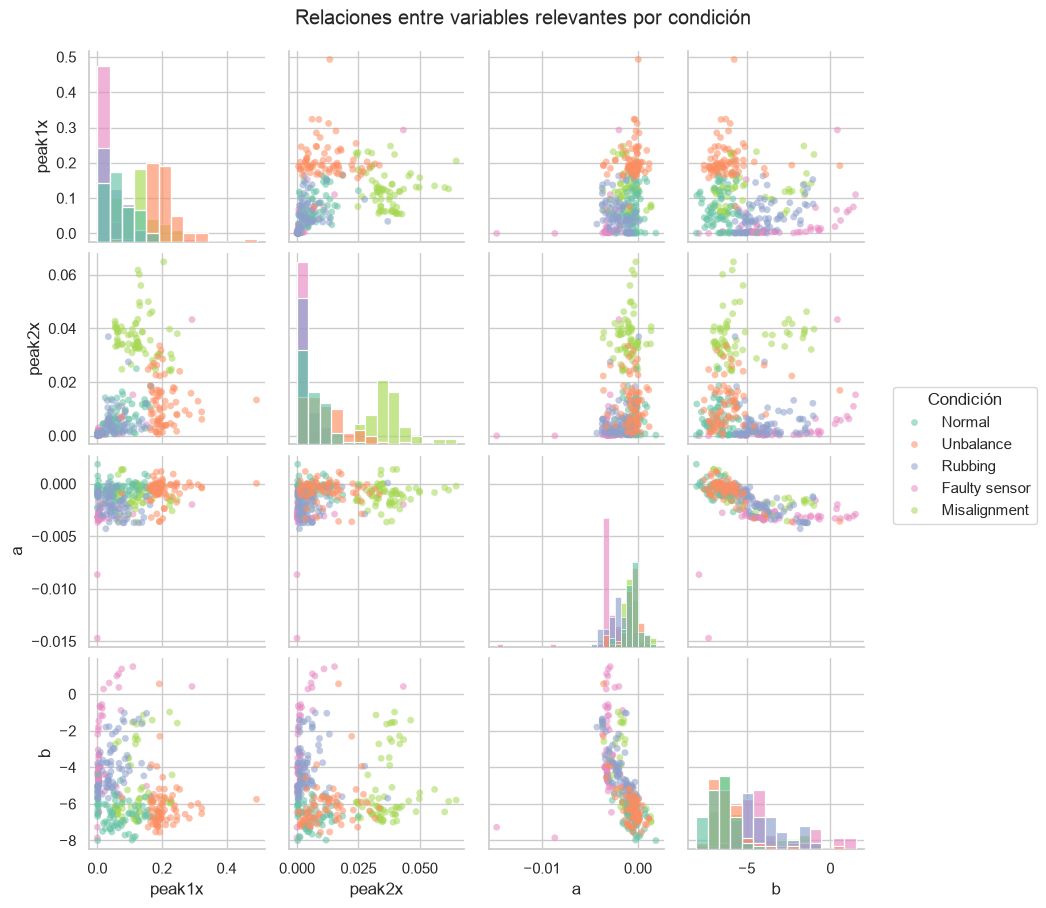

In [24]:
variables_pairplot = [
    "peak1x",
    "peak2x",
    "a",
    "b"
]

muestra_pairplot = (
    df.groupby("label", group_keys=False)
    .sample(n=70, random_state=42)
)

grafico_pairplot = sns.pairplot(
    data=muestra_pairplot,
    vars=variables_pairplot,
    hue="label",
    hue_order=orden_condiciones,
    palette=paleta_condiciones,
    diag_kind="hist",
    height=2.3,
    aspect=1,
    plot_kws={"alpha": 0.55, "s": 24, "edgecolor": "none"},
    diag_kws={"alpha": 0.65}
)

grafico_pairplot.fig.subplots_adjust(right=0.82, top=0.94)
sns.move_legend(
    grafico_pairplot,
    "center right",
    bbox_to_anchor=(0.99, 0.5),
    frameon=True,
    title="Condición"
)
grafico_pairplot.fig.suptitle(
    "Relaciones entre variables relevantes por condición",
    y=0.985
)
plt.show()


El pairplot confirma que las condiciones no forman grupos completamente separados en todas las combinaciones. `peak1x` aporta una señal distintiva para `Unbalance` y `peak2x` para `Misalignment`, mientras que varias combinaciones mantienen una superposición considerable entre `Normal`, `Rubbing` y `Faulty sensor`. También permite observar la relación inversa entre `a` y `b` desde otra perspectiva.

La muestra balanceada facilita la comparación visual, pero no representa la frecuencia real de cada condición.

<a id="seccion-5-4"></a>
### 5.4. Correlación según grupo operativo

La correlación global puede ocultar comportamientos diferentes entre el funcionamiento normal y las observaciones con fallas. Por eso se compara la relación entre `median(8,13)` y `median(98,102)` en dos grupos: `Normal` y el conjunto de todas las fallas.


In [25]:
variable_x = "median(8,13)"
variable_y = "median(98,102)"

grupos_operativos = {
    "Normal": df[df["label"] == "Normal"],
    "Fallas (todas)": df[df["label"] != "Normal"]
}

resultados_correlacion = []

for nombre_grupo, datos_grupo in grupos_operativos.items():
    resultados_correlacion.append({
        "grupo": nombre_grupo,
        "observaciones": len(datos_grupo),
        "correlacion_pearson": datos_grupo[variable_x].corr(
            datos_grupo[variable_y]
        )
    })

correlacion_por_grupo = (
    pd.DataFrame(resultados_correlacion)
    .set_index("grupo")
    .round(3)
)

correlacion_por_grupo


,observaciones,correlacion_pearson
grupo,,
Normal,4801,0.395
Fallas (todas),1231,0.784


La asociación cambia de forma importante: en `Normal` la correlación es aproximadamente 0,395, mientras que en el conjunto de fallas aumenta a 0,784. Esto sugiere que la relación entre ambas características es más intensa cuando se agrupan las condiciones de falla.

El resultado debe interpretarse con cautela: el grupo `Fallas (todas)` combina cuatro condiciones diferentes y la correlación no demuestra causalidad. Aun así, la diferencia muestra por qué segmentar el análisis puede revelar comportamientos que la correlación global —aproximadamente 0,755— no permite distinguir.

<a id="seccion-5-5"></a>
### 5.5. Interpretación de las correlaciones

La matriz global muestra el grado de asociación lineal entre las variables numéricas:

- La relación positiva más marcada se encuentra entre `median(8,13)` y `median(98,102)`, con una correlación aproximada de 0,76.
- La relación negativa más marcada aparece entre `a` y `b`, con un valor aproximado de −0,58.
- `rms(98,102)` y `peak1x` presentan una correlación positiva moderada de aproximadamente 0,51.
- Las demás relaciones son principalmente débiles o moderadas.

La comparación segmentada añade un matiz relevante: la relación entre las dos medianas es moderada en `Normal` (≈0,395) y fuerte cuando se agrupan las fallas (≈0,784). Por lo tanto, la intensidad de una asociación global no necesariamente representa de igual manera todos los estados operativos.

No se observan correlaciones lineales cercanas a 1 o −1 entre variables diferentes. Este análisis no demuestra causalidad ni descarta relaciones no lineales. Todas las variables se conservan porque esta etapa busca describir el conjunto de datos, no seleccionar variables para un modelo.


<a id="seccion-6"></a>
## 6. Conclusiones

El análisis exploratorio permitió conocer la estructura, calidad y comportamiento general de las características extraídas de las señales de vibración:

- El dataset contiene 6.032 observaciones correspondientes a 11 bombas y cinco condiciones de funcionamiento. No se detectaron valores nulos ni registros completamente duplicados.
- La distribución de las condiciones es desigual: `Normal` representa el 79,59 % de las observaciones, mientras que `Misalignment` representa el 1,16 %. Esta composición es relevante para comprender el dataset, pero no representa directamente la frecuencia de las condiciones durante la operación en campo.
- La cobertura también es desigual entre equipos: `Normal` y `Unbalance` aparecen en las 11 bombas; `Faulty sensor` y `Rubbing`, en 7; y `Misalignment`, únicamente en las bombas 4 y 9.
- Algunas variables presentan distribuciones asimétricas y valores extremos. Estos registros se conservaron porque no existen evidencias suficientes para considerarlos errores.
- `Unbalance` presenta valores centrales elevados de `peak1x`, mientras que `Misalignment` se distingue especialmente en `peak2x`. Los violin plots y los intervalos intercuartílicos cuantifican estas diferencias. El comportamiento es coherente con firmas clásicas de vibración asociadas con desbalanceo y desalineación, aunque no permite establecer por sí solo un diagnóstico mecánico.
- El scatterplot y el pairplot muestran que también existe solapamiento, especialmente entre `Normal`, `Rubbing` y `Faulty sensor`. Por eso ninguna variable aislada explica completamente la condición de una bomba.
- La correlación positiva global más marcada aparece entre `median(8,13)` y `median(98,102)` (≈0,755), pero cambia según el grupo: ≈0,395 en `Normal` y ≈0,784 al reunir las fallas.
- La relación negativa global más marcada se observa entre `a` y `b`, con aproximadamente −0,58.
- La distribución desigual de las condiciones y su cobertura por bomba no se consideran defectos que deban ocultarse o corregirse durante el EDA: son diagnósticos del conjunto de datos que deberán orientar cualquier análisis posterior.


<a id="seccion-7"></a>
## 7. Limitaciones del análisis

- Esta entrega es un análisis exploratorio sin modelado. Describe asociaciones y diferencias observadas, pero no demuestra causalidad ni capacidad predictiva.
- Las señales fueron adquiridas durante ensayos previos a la instalación definitiva de los equipos; por lo tanto, la distribución de las condiciones no representa directamente su frecuencia durante la operación en campo.
- El conjunto incluye solamente 11 bombas y varias observaciones pertenecen a un mismo equipo, por lo que no necesariamente son independientes entre sí.
- Algunas condiciones están concentradas en pocos equipos. En particular, `Misalignment` aparece únicamente en las bombas 4 y 9; sus patrones también podrían reflejar características particulares de esos equipos.
- Se trabaja con características previamente extraídas y no con las señales de vibración originales. Tampoco se dispone de dirección de medición o información de fase para realizar un diagnóstico mecánico completo.
- No se dispone de información temporal, variables operativas, historial de mantenimiento o contexto sobre cada evento.
- El pairplot utiliza una muestra balanceada únicamente para facilitar la comparación visual y no representa la frecuencia real de las condiciones.
- El grupo `Fallas (todas)` reúne cuatro condiciones heterogéneas; su correlación no sustituye un análisis individual por tipo de falla.
- La interpretación física de `peak1x` y `peak2x` es una hipótesis coherente con principios de análisis de vibraciones, pero no fue validada por especialistas y no constituye por sí sola un diagnóstico.


<a id="seccion-8"></a>
## 8. Posibles aplicaciones y próximos pasos

1. Comparar sistemáticamente el comportamiento de las variables entre bombas para separar el efecto del equipo del efecto de la condición.
2. Validar con especialistas en vibraciones y mantenimiento la interpretación de `peak1x`, `peak2x`, los valores extremos y las diferencias observadas.
3. Ampliar la cantidad de equipos que presentan condiciones poco representadas, especialmente `Misalignment`.
4. Incorporar, si estuvieran disponibles, señales originales, dirección de medición, información de fase, variables operativas, fechas, condiciones de carga e historial de mantenimiento.
5. Crear un tablero interactivo que permita explorar condiciones, variables y equipos.
6. Organizar los datos en una base SQL para practicar consultas e indicadores.
7. Evaluar modelos más adelante utilizando una separación por `esp_id` y métricas que permitan revisar el desempeño de cada condición. En esa etapa también podría estudiarse, con mayor profundidad, si conviene aplicar remuestreo, clasificación multiclase o detección de anomalías.
